In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Jungle](https://www.openml.org/search?type=data&status=active&id=41027)

In [2]:
dataset_id = 41027
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr, multi=True)

[I 2025-04-21 18:43:29,088] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 18:43:29,131] Trial 0 finished with value: 0.8032642858654641 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.8032642858654641.
[I 2025-04-21 18:43:29,186] Trial 1 finished with value: 0.8034527808192338 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 1 with value: 0.8034527808192338.
[I 2025-04-21 18:43:29,245] Trial 2 finished with value: 0.8034414558903292 and parameters: {'penalty': 'l2', 'C': 1}. Best is trial 1 with value: 0.8034527808192338.
[I 2025-04-21 18:43:29,305] Trial 3 finished with value: 0.8032642858654641 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 1 with value: 0.8034527808192338.
[I 2025-04-21 18:43:29,368] Trial 4 finished with value: 0.8034416094867418 and parameters: {'penalty': 'l2', 'C': 10}. Best is trial 1 with value: 0.8034527808192338.
[I 2025-04-21 18:43:29,429] Trial 5 finished with 

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb, multi=True)

[I 2025-04-21 18:43:36,741] A new study created in memory with name: catboost_optimization
[I 2025-04-21 18:43:42,002] Trial 0 finished with value: 0.9560927245460557 and parameters: {'depth': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.9560927245460557.
[I 2025-04-21 18:43:45,187] Trial 1 finished with value: 0.9725798285183593 and parameters: {'depth': 6, 'learning_rate': 0.3, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.9725798285183593.
[I 2025-04-21 18:43:49,165] Trial 2 finished with value: 0.9651307582737157 and parameters: {'depth': 8, 'learning_rate': 0.3, 'l2_leaf_reg': 3.0}. Best is trial 1 with value: 0.9725798285183593.
[I 2025-04-21 18:43:52,441] Trial 3 finished with value: 0.973581138606343 and parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0}. Best is trial 3 with value: 0.973581138606343.
[I 2025-04-21 18:43:56,481] Trial 4 finished with value: 0.9707192518335273 and parameters: {'depth': 8, 'learning_rate': 0

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm, multi=True)

[I 2025-04-21 18:44:54,087] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 18:44:58,368] Trial 0 finished with value: 0.9750241522423403 and parameters: {'num_leaves': 32, 'reg_alpha': 0.01, 'reg_lambda': 1e-06, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9750241522423403.
[I 2025-04-21 18:46:11,951] Trial 1 finished with value: 0.9737574641007377 and parameters: {'num_leaves': 4096, 'reg_alpha': 0.1, 'reg_lambda': 1e-07, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9750241522423403.
[I 2025-04-21 18:46:37,063] Trial 2 finished with value: 0.967782628011221 and parameters: {'num_leaves': 2048, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9750241522423403.
[I 2025-04-21 18:46:39,847] Trial 3 finished with value: 0.9803951510839478 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-05, 'reg_lambda': 1.0, 'learning_rate': 0.3}. Best is trial 3 with value: 0.9803951510839478.
[I 2025-04-21 18:47:3

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


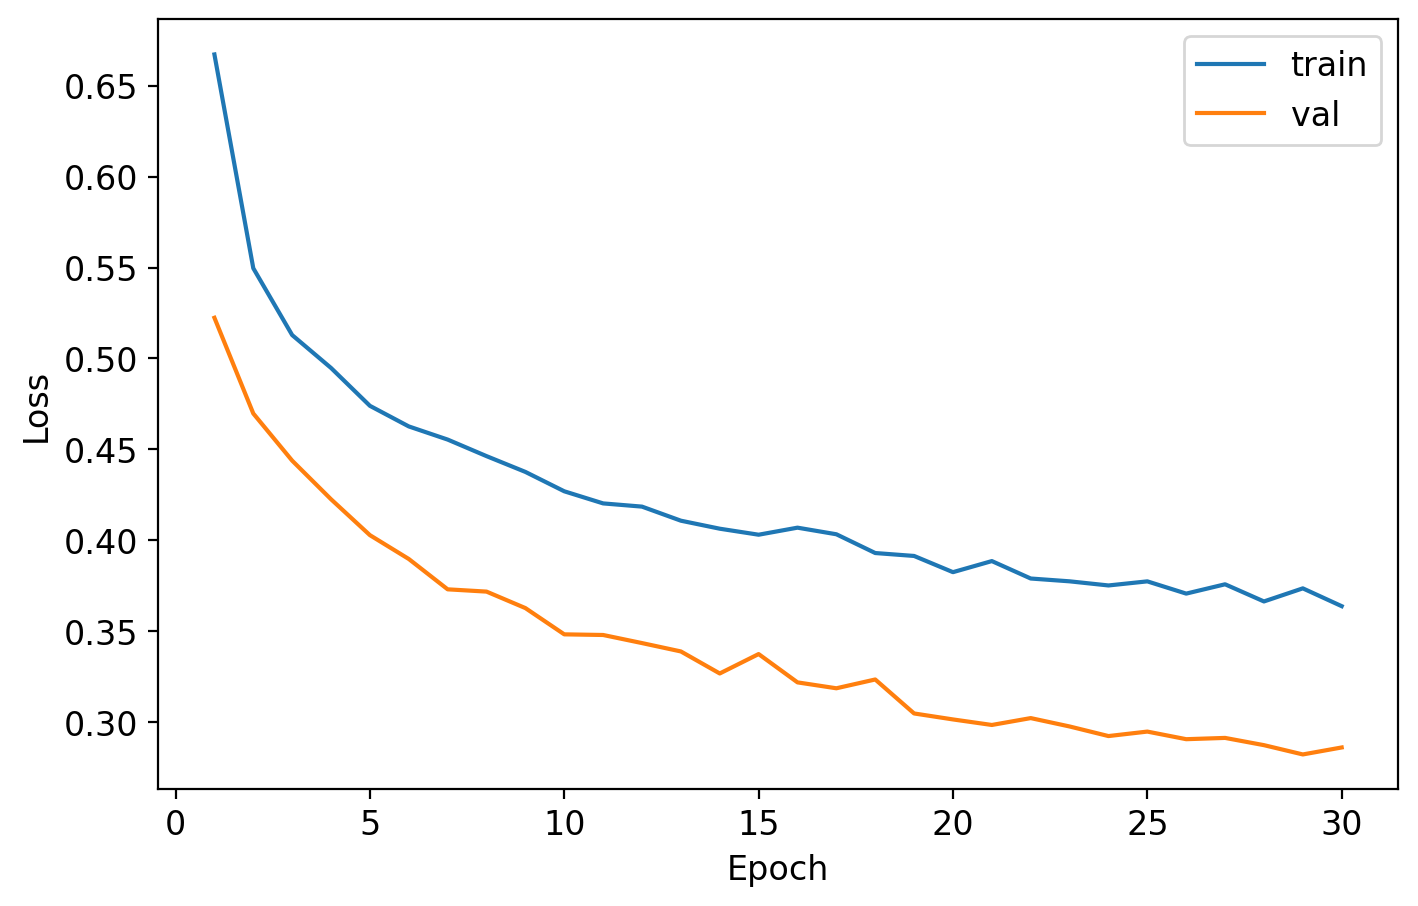

Epoch 30: train loss = 0.3638; valid loss = 0.2862


In [11]:
net = TABMLP(len(numerical_features), emb_dims, num_classes=len(np.unique(y_train))).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 30, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device, multi=True)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob, multi=True)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.8146±0.0051,0.4843±0.0060,0.6844±0.0070,0.5710±0.0381,0.5020±0.0049
1,CatBoost,0.9764±0.0014,0.8288±0.0076,0.8705±0.0051,0.8378±0.0083,0.8211±0.0082
2,LightGBM,0.9812±0.0012,0.8309±0.0077,0.8739±0.0051,0.8422±0.0082,0.8214±0.0085
3,TABMLP,0.9719±0.0016,0.8194±0.0078,0.8650±0.0052,0.8293±0.0084,0.8109±0.0084
